## Import ##

In [34]:
# LOCATION : https://github.com/purnasai/Dino_V2
import torch
from torchvision import models, transforms
import cv2
import os
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from PIL import Image
import pickle
from time import gmtime, strftime

os.environ["XFORMERS_DISABLED"] = "1" # Switch to enable xFormers
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [35]:
import sys
REPO_PATH = "/home/osero/Desktop/CMPE/dinov2" # Specify a local path to the repository (or use installed package instead)
sys.path.append(REPO_PATH)

In [36]:
import dinov2_utils

extractor = dinov2_utils.DinoFeatureExtractor(model_name="dinov2_version=vitl14-reg_stride=14_facet=token_layer=23_norm=1")
extractor.to(device)

# dino_model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitl14').to(device)
# dino_model.to(device)
# dino_model.eval()

# Define transform to match the input size for the model
# transform = transforms.Compose([
#     transforms.Resize((224, 224)),
#     transforms.ToTensor(),
#     transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
# ])

transform = transforms.Compose([           
                                transforms.Resize(256),                    
                                transforms.CenterCrop(224),               
                                transforms.ToTensor(),                    
                                transforms.Normalize(                      
                                mean=[0.485, 0.456, 0.406],                
                                std=[0.229, 0.224, 0.225]              
                                )])

Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitl14/dinov2_vitl14_reg4_pretrain.pth" to /home/osero/.cache/torch/hub/checkpoints/dinov2_vitl14_reg4_pretrain.pth
100%|██████████| 1.13G/1.13G [01:42<00:00, 11.8MB/s]


## Functions ##

In [ ]:
# from typing import Any, Dict, List, NamedTuple, Optional
# from sklearn.decomposition import PCA

# def tensor_to_array(tensor: torch.Tensor) -> np.ndarray:
#     """Converts a tensor into a Numpy array.

#     Args:
#         tensor: A tensor (may be in the GPU memory).
#     Returns:
#         A Numpy array.
#     """

#     return tensor.detach().cpu().numpy()

# class FeatureOpts(NamedTuple):
#     extractor_name: str

# class PCAProjector(Projector):
#     def __init__(
#         self, n_components: int, whiten: bool = False, **kwargs: Dict[str, Any]
#     ) -> None:
#         self.n_components: int = n_components
#         self.whiten: bool = whiten
#         self.pca: Any = PCA(n_components=n_components, whiten=whiten)

#     def fit(
#         self, data_x: torch.Tensor, data_y: Optional[torch.Tensor] = None, **kwargs: Any
#     ) -> None:

#         # Cap the number of feature vectors for PCA fitting.
#         if "max_samples" in kwargs:
#             if data_x.shape[0] > kwargs["max_samples"]:
#                 perm = torch.randperm(data_x.shape[0])
#                 sampled_ids = perm[: kwargs["max_samples"]]
#                 data_x = data_x[sampled_ids]

#         self.pca.fit(tensor_to_array(data_x))

#     def transform(self, data_x: torch.Tensor) -> torch.Tensor:
#         return array_to_tensor(self.pca.transform(tensor_to_array(data_x))).to(
#             data_x.device
#         )
    
# class FeatureBasedObjectRepre:
#     """Stores visual object features registered in 3D."""

#     # 3D vertices of the object model of shape (num_vertices, 3).
#     vertices: Optional[torch.Tensor] = None

#     # 3D vertex normals of shape (num_vertices, 3).
#     vertex_normals: Optional[torch.Tensor] = None

#     # Feature vectors of shape (num_features, feat_dims).
#     feat_vectors: Optional[torch.Tensor] = None

#     # Feature options.
#     feat_opts: Optional[FeatureOpts] = None

#     # Mapping from feature to associated vertex ID of shape (num_features).
#     feat_to_vertex_ids: Optional[torch.Tensor] = None

#     # Mapping from feature to source template ID of shape (num_features).
#     feat_to_template_ids: Optional[torch.Tensor] = None

#     # Mapping from feature to assigned feature ID of shape (num_features).
#     feat_to_cluster_ids: Optional[torch.Tensor] = None

#     # Centroids of feature clusters of shape (num_clusters, feat_dims).
#     feat_cluster_centroids: Optional[torch.Tensor] = None

#     # Inverse document frequency (for tfidf template descriptors) of shape (num_clusters).
#     # Ref: https://www.di.ens.fr/~josef/publications/torii13.pdf
#     feat_cluster_idfs: Optional[torch.Tensor] = None

#     # Projectors of raw extracted features to features saved in `self.feat_vectors`.
#     feat_raw_projectors: List[projector_util.Projector] = field(default_factory=list)

#     # Projectors for visualizing features from `self.feat_vectors` (typically a PCA projector).
#     feat_vis_projectors: List[projector_util.Projector] = field(default_factory=list)

#     # Templates of shape (num_templates, channels, height, width).
#     templates: Optional[torch.Tensor] = None

#     # Per-template camera with extrinsics expressed as a transformation from the model space
#     # to the camera space.
#     template_cameras_cam_from_model: List[PinholePlaneCameraModel] = field(default_factory=list)

#     # Template descriptors of shape (num_templates, desc_dims).
#     template_descs: Optional[torch.Tensor] = None

#     # Configuration of template descriptors.
#     template_desc_opts: Optional[TemplateDescOpts] = None

total_features.shape:  torch.Size([24, 256, 1024])


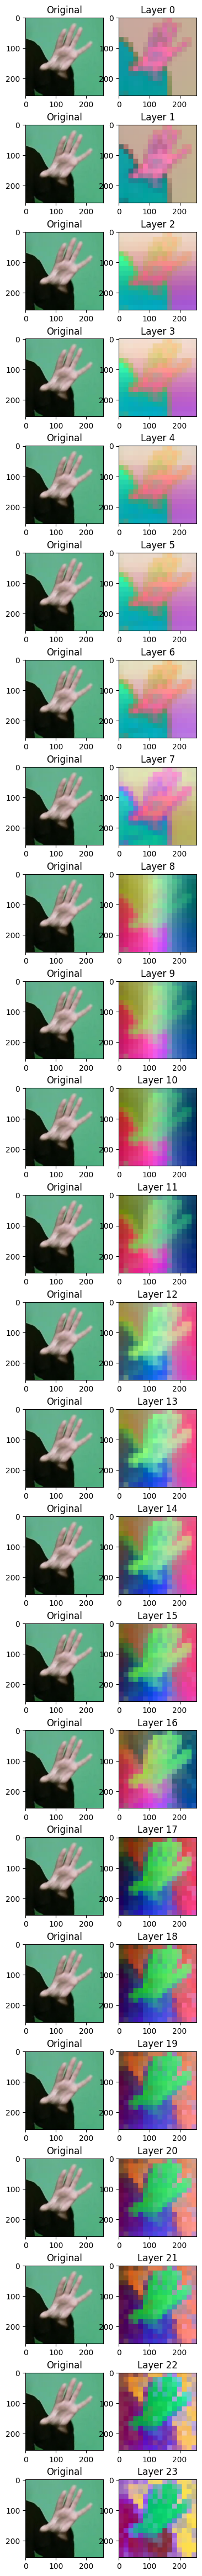

In [42]:
import math
from vis_util import vis_pca_feature_map
from matplotlib import pyplot as plt

total_features  = []
total_images  = []

image = Image.open('/media/osero/SamsungSSD/CMPE_SSD/frame-hand_left-c256/0001/User_2_001/015.jpg')
transformed_image = transform(image).unsqueeze(0).to(device)
first_layer = 0
all_layers = range(first_layer,24)

plt.figure(figsize=(4,2.5 * len(all_layers)))

with torch.no_grad():
  for idx, layer in enumerate(all_layers):
    extractor_output = extractor(transformed_image,layer=layer)
    extractor_output_transformed = extractor_output['feature_maps'].view(1, 1024, -1).permute(0, 2, 1)
    total_images.append(image)
    total_features.append(extractor_output_transformed)

    query_feat_vis = vis_pca_feature_map(
      feature_map_chw=extractor_output['feature_maps'][0],
      image_height=image.height,
      image_width=image.width,
    )
    plt.subplot(len(all_layers), 2, (2*idx)+1)
    plt.imshow(total_images[idx])
    plt.title(f"Original")
    plt.subplot(len(all_layers), 2, (2*idx)+2)
    plt.imshow(query_feat_vis)
    plt.title(f"Layer {layer}")

# plt.suptitle("FoundPose_PCA_right_hand")
plt.savefig('FoundPose_PCA_left_hand_reg.png')
total_features = torch.cat(total_features, dim=0)
number_of_images = total_features.shape[0]
feat_dim = total_features.shape[2]
patch_size = int(math.sqrt(total_features.shape[1]))
print('total_features.shape: ', total_features.shape)

aaa = 5

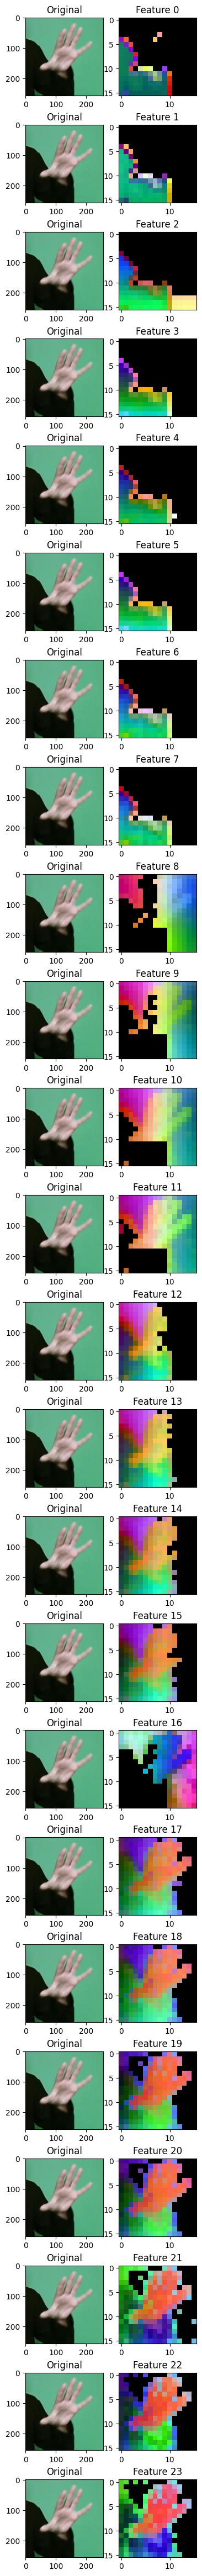

In [44]:
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA

def visualize_PCA(total_features, total_images, patch_size, feat_dim):
    sample_number = len(total_images)
    plt.figure(figsize=(4,2.5 * sample_number))
    number_of_images = 1
    for idx, feature in enumerate(total_features[0:sample_number]):
        reshaped_features = feature.reshape(number_of_images * patch_size * patch_size, feat_dim).cpu()#4(*H*w, 1024)
        pca = PCA(n_components=3)
        pca.fit(reshaped_features)
        pca_features = pca.transform(reshaped_features)

        pca_features[:, 0] = (pca_features[:, 0] - pca_features[:, 0].min()) / \
                     (pca_features[:, 0].max() - pca_features[:, 0].min())
        
        # segment/seperate the backgound and foreground using the first component
        pca_features_bg = pca_features[:, 0] > 0.7 # from first histogram
        pca_features_fg = ~pca_features_bg

        # 2nd PCA for only foreground patches
        pca.fit(reshaped_features[pca_features_fg]) 
        pca_features_left = pca.transform(reshaped_features[pca_features_fg])

        for i in range(3):
            # min_max scaling
            pca_features_left[:, i] = (pca_features_left[:, i] - pca_features_left[:, i].min()) / (pca_features_left[:, i].max() - pca_features_left[:, i].min())

        pca_features_rgb = pca_features.copy()
        # for black background
        pca_features_rgb[pca_features_bg] = 0
        # new scaled foreground features
        pca_features_rgb[pca_features_fg] = pca_features_left

        # reshaping to numpy image format
        pca_features_rgb = pca_features_rgb.reshape(number_of_images, patch_size, patch_size, 3)
        plt.subplot(sample_number, 2, (2*idx)+1)
        plt.imshow(total_images[idx])
        plt.title(f"Original")
        plt.subplot(sample_number, 2, (2*idx)+2)
        plt.imshow(pca_features_rgb[0])
        plt.title(f"Feature {first_layer + idx}")
    plt.savefig('Custom_PCA_left_hand_reg.png')


visualize_PCA(total_features, total_images, patch_size, feat_dim)

In [ ]:

# image = Image.open('/media/osero/SamsungSSD/CMPE_SSD/frame-hand_left-c256/0001/User_2_001/001.jpg')
# image = transform(image).unsqueeze(0).to(device)

# extractor_output = extractor(image)
# test = dino_model(image)
# aaa = 5

## Process ##

In [ ]:
try:
    # Step 4: Process All Videos in the Dataset
    # Set paths to your video dataset and labels
    video_folder = "/media/osero/SamsungSSD/CMPE_SSD/frame-face-c256" 
    pickle_saved_file_path = '/media/osero/SamsungSSD/features_face_large_saved.pickle'
    video_labels = []  # Populate this with the corresponding labels for each video
    video_embeddings = []
    initial_label = 0
    process_count = 0

    if os.path.isfile(pickle_saved_file_path):
        pickle_file11 = open(pickle_saved_file_path, 'rb')
        video_embeddings,video_labels = pickle.load(pickle_file11)
        initial_label = video_labels[-1]
        print("initial_label is: ", initial_label)

    for label_folder in sorted(os.listdir(video_folder)):
        process_count += 1
        full_label_folder = os.path.join(video_folder, label_folder)
        label = int(label_folder)
        if label <= initial_label:
            continue
        print("process_count: ", process_count, ' , label: ', label)
        for sample_folder in sorted(os.listdir(full_label_folder)):
            full_sample_folder = os.path.join(full_label_folder, sample_folder)
            image_list = []
            for image_file in sorted(os.listdir(full_sample_folder)):
                full_image_file = os.path.join(full_sample_folder, image_file)
                image = Image.open(full_image_file)
                image = transform(image)
                image_list.append(image)
            video_embedding = extract_video_embedding(image_list)
            video_embeddings.append(video_embedding)
            video_labels.append(label)
        if(process_count % 10 == 0):
            with open(pickle_saved_file_path, 'wb') as handle:
                pickle.dump((video_embeddings, video_labels), handle, protocol=pickle.HIGHEST_PROTOCOL)

    with open('/media/osero/SamsungSSD/CMPE_SSD/features_face_large.pickle', 'wb') as handle:
        pickle.dump((video_embeddings, video_labels), handle, protocol=pickle.HIGHEST_PROTOCOL)
    abc = 4

except Exception as error:
    # handle the exception
    print("An exception occurred:", error) # An exception occurred: division by zero


In [ ]:
# @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
# @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@ DEMO @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@
# @@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@@

try:
    # Step 4: Process All Videos in the Dataset
    # Set paths to your video dataset and labels
    video_folder = "/media/osero/SamsungSSD/CMPE_SSD/frame-face-c256" 
    pickle_saved_file_path = '/media/osero/SamsungSSD/features_face_large_saved.pickle'
    video_labels = []  # Populate this with the corresponding labels for each video
    video_embeddings = []
    initial_label = 0
    process_count = 0

    if os.path.isfile(pickle_saved_file_path):
        pickle_file11 = open(pickle_saved_file_path, 'rb')
        video_embeddings,video_labels = pickle.load(pickle_file11)   

        first_index = video_labels.index(720)
        video_embeddings = video_embeddings[0:first_index]
        video_labels = video_labels[0:first_index]
        
        initial_label = video_labels[-1]
        print("initial_label is: ", initial_label)

    for label_folder in sorted(os.listdir(video_folder)):
        process_count += 1
        full_label_folder = os.path.join(video_folder, label_folder)
        label = int(label_folder)
        if label <= initial_label:
            continue
        print("process_count: ", process_count, ' , label: ', label)
        for sample_folder in sorted(os.listdir(full_label_folder)):
            full_sample_folder = os.path.join(full_label_folder, sample_folder)
            image_list = []
            for image_file in sorted(os.listdir(full_sample_folder)):
                full_image_file = os.path.join(full_sample_folder, image_file)
                image = Image.open(full_image_file)
                image = transform(image)
                image_list.append(image)
            video_embedding = extract_video_embedding_single(image_list)
            video_embeddings.append(video_embedding)
            video_labels.append(label)
        if(process_count % 10 == 0):
            with open(pickle_saved_file_path, 'wb') as handle:
                pickle.dump((video_embeddings, video_labels), handle, protocol=pickle.HIGHEST_PROTOCOL)

    with open('/media/osero/SamsungSSD/CMPE_SSD/features_face_large.pickle', 'wb') as handle:
        pickle.dump((video_embeddings, video_labels), handle, protocol=pickle.HIGHEST_PROTOCOL)
    abc = 4

except Exception as error:
    # handle the exception
    print("An exception occurred:", error) # An exception occurred: division by zero


In [1]:
import pickle
import os

pickle_file = open('/media/osero/SamsungSSD/CMPE_SSD/features_face_large.pickle', 'rb')
features, labels = pickle.load(pickle_file)

paths = []
train_paths = []
train_features = []
train_labels = []
test_paths = []
test_features = []
test_labels = []

video_folder = "/media/osero/SamsungSSD/CMPE_SSD/frame-face-c256" 

for label_folder in sorted(os.listdir(video_folder)):
    full_label_folder = os.path.join(video_folder, label_folder)
    for sample_folder in sorted(os.listdir(full_label_folder)):
        full_sample_folder = os.path.join(full_label_folder, sample_folder)
        paths.append(full_sample_folder)

for i, path in enumerate(paths):
    user_name = paths[i].split('/')[-1].lower()
    if 'user_4' in user_name:
        test_paths.append(paths[i])
        test_features.append(features[i])
        test_labels.append(labels[i])
    else:
        train_paths.append(paths[i])
        train_features.append(features[i])
        train_labels.append(labels[i])


with open('/media/osero/SamsungSSD/pickles/features_face_frames_large_train.pickle', 'wb') as handle:
    pickle.dump((train_paths, train_features, train_labels), handle, protocol=pickle.HIGHEST_PROTOCOL)


with open('/media/osero/SamsungSSD/pickles/features_face_frames_large_test.pickle', 'wb') as handle:
    pickle.dump((test_paths, test_features, test_labels), handle, protocol=pickle.HIGHEST_PROTOCOL)

cc = 4

## Evaluation ##

In [8]:
# with open('features_face_frames_small.pickle', 'wb') as handle:
#     pickle.dump((video_embeddings, video_labels), handle, protocol=pickle.HIGHEST_PROTOCOL)

In [9]:
# pickle_file11 = open('features_right_hand_large_trained_mixed_saved.pickle', 'rb')
# features11,labels11 = pickle.load(pickle_file11)
# tcc = 5